In [1]:
import random
import os
from collections import Counter

import spacy
from spacy.tokens import DocBin
from spacy.training import Example
from spacy.util import minibatch, compounding
from tqdm.auto import tqdm

os.makedirs('', exist_ok=True)
print(f'spaCy {spacy.__version__}')

spaCy 3.8.14


In [2]:
nlp_blank = spacy.blank('ru')
for split, path in [('train', '../data_spacy/train_combo.spacy'), ('dev', '../data_spacy/dev_combo.spacy')]:
    db = DocBin().from_disk(path)
    docs = list(db.get_docs(nlp_blank.vocab))
    counts = Counter(e.label_ for d in docs for e in d.ents)
    n_ents = sum(len(d.ents) for d in docs)
    print(f'{split}: {len(docs)} docs, {n_ents} entities | {dict(counts)}')

train: 11729 docs, 9692 entities | {'NAME': 5413, 'ADDRESS': 4279}
dev: 1304 docs, 1065 entities | {'NAME': 581, 'ADDRESS': 484}


In [3]:
nlp = spacy.load('ru_core_news_lg')
print('Исходный пайплайн:', nlp.pipe_names)

# Оставляем только tok2vec, убираем всё остальное
for pipe in [p for p in nlp.pipe_names if p != 'tok2vec']:
    nlp.remove_pipe(pipe)

# Добавляем чистую NER-голову под наши два класса
ner = nlp.add_pipe('ner', last=True)
ner.add_label('NAME')
ner.add_label('ADDRESS')

print('Итоговый пайплайн:', nlp.pipe_names)
print('NER метки:', ner.labels)

Исходный пайплайн: ['tok2vec', 'morphologizer', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']
Итоговый пайплайн: ['tok2vec', 'ner']
NER метки: ('ADDRESS', 'NAME')


In [4]:
def load_examples(path, nlp):
    db = DocBin().from_disk(path)
    return [Example(nlp.make_doc(d.text), d) for d in db.get_docs(nlp.vocab)]

train_ex = load_examples('../data_spacy/train_combo.spacy', nlp)
dev_ex   = load_examples('../data_spacy/dev_combo.spacy', nlp)
print(f'train={len(train_ex)}  dev={len(dev_ex)}')

train=11729  dev=1304


In [5]:
N_EPOCHS = 10
DROPOUT  = 0.2
# DROPOUT  = 0.1
PATIENCE = 5

In [6]:
# initialize() сохраняет веса tok2vec (уже загружены из ru_core_news_lg),
# инициализирует только NER-голову
optimizer = nlp.initialize(lambda: train_ex)
optimizer.learn_rate = 5e-4

best_macro = 0.0
no_improve  = 0
history = {'loss': [], 'f_name': [], 'f_addr': [], 'macro': []}

In [7]:
for epoch in range(1, N_EPOCHS + 1):
    random.shuffle(train_ex)
    losses = {}
    # batches = list(minibatch(train_ex, size=compounding(4.0, 32.0, 1.001)))
    batches = list(minibatch(train_ex, size=compounding(8.0, 64.0, 1.001)))
    for batch in tqdm(batches, desc=f'Epoch {epoch:2d}', leave=False):
        nlp.update(batch, sgd=optimizer, drop=DROPOUT, losses=losses)

    sc = nlp.evaluate(dev_ex)
    pt = sc.get('ents_per_type', {})
    f_name = pt.get('NAME',    {}).get('f', 0.0)
    f_addr = pt.get('ADDRESS', {}).get('f', 0.0)
    macro  = (f_name + f_addr) / 2

    history['loss'].append(losses.get('ner', 0))
    history['f_name'].append(f_name)
    history['f_addr'].append(f_addr)
    history['macro'].append(macro)

    mark = ' ← best' if macro > best_macro else ''
    print(
        f'Epoch {epoch:2d} | loss={losses.get("ner", 0):7.1f} '
        f'| NAME={f_name:.3f}  ADDR={f_addr:.3f}  macro={macro:.3f}{mark}'
    )

    if macro > best_macro:
        best_macro = macro
        no_improve = 0
        nlp.to_disk('../ft_spacy/model-best')
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f'Early stop (patience={PATIENCE})')
            break

print(f'\nBest macro F1 = {best_macro:.3f}')

Epoch  1:   0%|          | 0/926 [00:00<?, ?it/s]

Epoch  1 | loss=13335.8 | NAME=0.776  ADDR=0.607  macro=0.691 ← best


Epoch  2:   0%|          | 0/926 [00:00<?, ?it/s]

Epoch  2 | loss= 6120.3 | NAME=0.816  ADDR=0.695  macro=0.756 ← best


Epoch  3:   0%|          | 0/926 [00:00<?, ?it/s]

...

Epoch  8 | loss= 2823.4 | NAME=0.857  ADDR=0.761  macro=0.809 ← best


Epoch  9:   0%|          | 0/926 [00:00<?, ?it/s]

Epoch  9 | loss= 2409.2 | NAME=0.855  ADDR=0.742  macro=0.799


Epoch 10:   0%|          | 0/926 [00:00<?, ?it/s]

Epoch 10 | loss= 2344.7 | NAME=0.855  ADDR=0.745  macro=0.800

Best macro F1 = 0.809


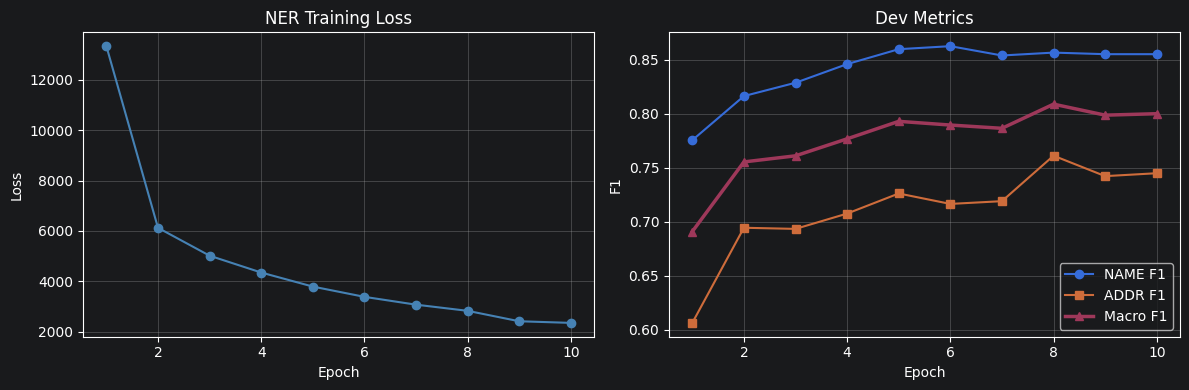

In [8]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(history['loss']) + 1))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history['loss'], marker='o', color='steelblue')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('NER Training Loss')
axes[0].grid(True, alpha=0.4)

axes[1].plot(epochs, history['f_name'], marker='o', label='NAME F1')
axes[1].plot(epochs, history['f_addr'], marker='s', label='ADDR F1')
axes[1].plot(epochs, history['macro'],  marker='^', label='Macro F1', linewidth=2.5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1')
axes[1].set_title('Dev Metrics')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

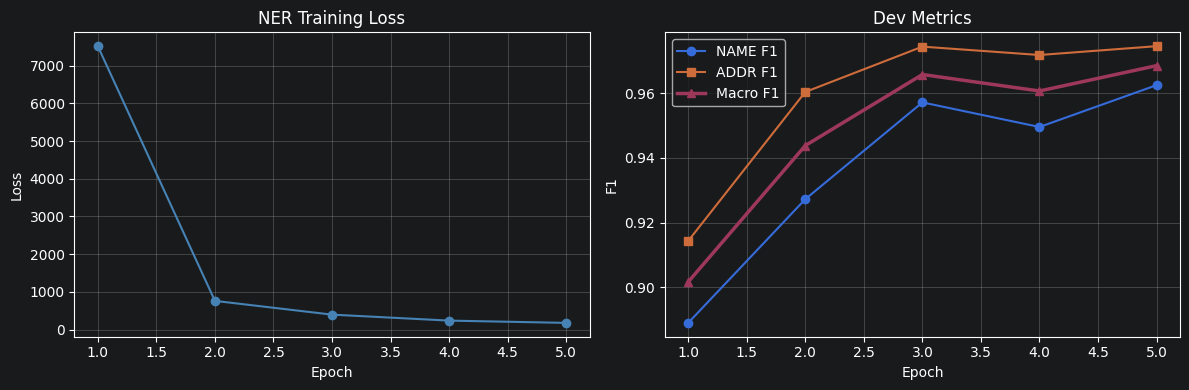

In [24]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(history['loss']) + 1))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history['loss'], marker='o', color='steelblue')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('NER Training Loss')
axes[0].grid(True, alpha=0.4)

axes[1].plot(epochs, history['f_name'], marker='o', label='NAME F1')
axes[1].plot(epochs, history['f_addr'], marker='s', label='ADDR F1')
axes[1].plot(epochs, history['macro'],  marker='^', label='Macro F1', linewidth=2.5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1')
axes[1].set_title('Dev Metrics')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

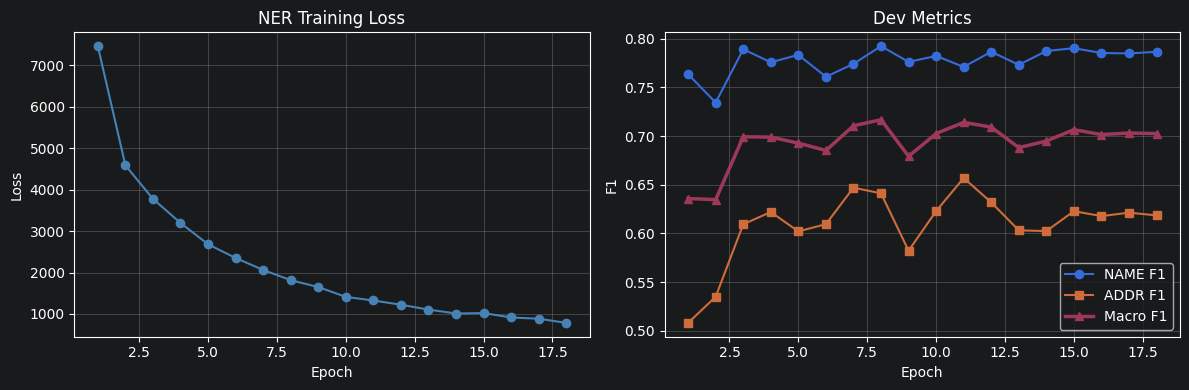

In [16]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(history['loss']) + 1))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history['loss'], marker='o', color='steelblue')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('NER Training Loss')
axes[0].grid(True, alpha=0.4)

axes[1].plot(epochs, history['f_name'], marker='o', label='NAME F1')
axes[1].plot(epochs, history['f_addr'], marker='s', label='ADDR F1')
axes[1].plot(epochs, history['macro'],  marker='^', label='Macro F1', linewidth=2.5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1')
axes[1].set_title('Dev Metrics')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

In [9]:
nlp_best = spacy.load('./model-best')
dev_ex_eval = load_examples('../data_spacy/dev_combo.spacy', nlp_best)
sc = nlp_best.evaluate(dev_ex_eval)
pt = sc.get('ents_per_type', {})

print('=== Dev-метрики (best model) ===')
for lbl in ('NAME', 'ADDRESS'):
    s = pt.get(lbl, {})
    print(f'  {lbl:8s}  P={s.get("p",0):.3f}  R={s.get("r",0):.3f}  F1={s.get("f",0):.3f}')
print(f'  {"Overall":8s}  P={sc["ents_p"]:.3f}  R={sc["ents_r"]:.3f}  F1={sc["ents_f"]:.3f}')

=== Dev-метрики (best model) ===
  NAME      P=0.844  R=0.869  F1=0.857
  ADDRESS   P=0.837  R=0.698  F1=0.761
  Overall   P=0.841  R=0.792  F1=0.816


In [10]:
nlp_best = spacy.load('./model-best')

TESTS = [
    'Иван Иванович Иванов живёт на улице Пушкина, д. 5',
    'Отправить документы Марии Петровне Соколовой: Санкт-Петербург, Невский пр., 10',
    'Контакт: Сидоров А.В., тел. +7 495 123-45-67',
    'Директор Соколова Е.М. переехала в г. Новосибирск, ул. Ленина, д. 12, кв. 34',
    'Паспорт выдан УФМС по г. Москве Прохорову Алексею Николаевичу',
]

for text in TESTS:
    doc = nlp_best(text)
    hi = text
    for ent in sorted(doc.ents, key=lambda e: e.start_char, reverse=True):
        hi = hi[:ent.start_char] + f'>>{ent.label_}:{hi[ent.start_char:ent.end_char]}<<' + hi[ent.end_char:]
    print(hi)

>>NAME:Иван Иванович Иванов<< живёт на >>ADDRESS:улице Пушкина, д. 5<<
Отправить документы >>NAME:Марии Петровне Соколовой<<: >>ADDRESS:Санкт-Петербург, Невский пр., 10<<
Контакт: >>NAME:Сидоров А.В.<<, тел. +7 495 123-45-67
Директор >>NAME:Соколова Е.М.<< переехала в >>ADDRESS:г. Новосибирск, ул. Ленина, д. 12, кв. 34<<
Паспорт выдан УФМС по г. >>ADDRESS:Москве<< >>NAME:Прохорову Алексею Николаевичу<<


In [14]:
from datasets import load_dataset
import pandas as pd
import numpy as np
from collections import Counter

TARGET_LABELS = {'NAME', 'ADDRESS'}

# Загружаем бенчмарк (domain ≈ 900 примеров, entity ≈ 910 примеров)
pii_bench = load_dataset('raft-security-lab/pii-bench')

# Лучшая сохранённая модель
nlp_eval = spacy.load('./model-best')

def normalize(text: str) -> str:
    """Нормализация: убираем лишние пробелы + приводим к нижнему регистру."""
    return ' '.join(text.strip().split()).lower()

records = []

for subset_name, subset_data in pii_bench.items():
    for example in subset_data:
        text = example['text']

        # Инференс — прогоняем ВСЕ примеры (не только те, где есть NAME/ADDRESS)
        doc = nlp_eval(text)

        # Предсказания модели: только NAME и ADDRESS
        pred_bag = Counter(
            (normalize(ent.text), ent.label_)
            for ent in doc.ents
            if ent.label_ in TARGET_LABELS
        )

        # Золото: только NAME и ADDRESS из pii-bench (остальные типы игнорируем)
        gold_bag = Counter(
            (normalize(text[e['start']:e['end']]), e['type'])
            for e in example['entities']
            if e['type'] in TARGET_LABELS
        )

        # Bag-matching: TP = min(pred, gold) для каждой пары (текст, метка)
        for key in gold_bag | pred_bag:
            tp_cnt = min(gold_bag[key], pred_bag[key])
            fp_cnt = max(0, pred_bag[key] - gold_bag[key])
            fn_cnt = max(0, gold_bag[key] - pred_bag[key])
            label  = key[1]
            records += [{'subset': subset_name, 'label': label, 'decision': 'TP'}] * tp_cnt
            records += [{'subset': subset_name, 'label': label, 'decision': 'FP'}] * fp_cnt
            records += [{'subset': subset_name, 'label': label, 'decision': 'FN'}] * fn_cnt

df_results = pd.DataFrame(records) if records else pd.DataFrame(
    columns=['subset', 'label', 'decision'])


def build_metrics(df: pd.DataFrame, labels=TARGET_LABELS) -> pd.DataFrame:
    rows = []
    for label in sorted(labels):
        sub = df[df['label'] == label]
        tp  = int((sub['decision'] == 'TP').sum())
        fp  = int((sub['decision'] == 'FP').sum())
        fn  = int((sub['decision'] == 'FN').sum())
        p   = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r   = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1  = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
        rows.append({'label': label, 'TP': tp, 'FP': fp, 'FN': fn,
                     'Precision': round(p, 3), 'Recall': round(r, 3), 'F1': round(f1, 3)})
    # Macro-average только по меткам, где хоть что-то есть
    valid = [r for r in rows if r['TP'] + r['FP'] + r['FN'] > 0]
    if valid:
        rows.append({
            'label':     '__macro__',
            'TP':        sum(r['TP'] for r in valid),
            'FP':        sum(r['FP'] for r in valid),
            'FN':        sum(r['FN'] for r in valid),
            'Precision': round(float(np.mean([r['Precision'] for r in valid])), 3),
            'Recall':    round(float(np.mean([r['Recall']    for r in valid])), 3),
            'F1':        round(float(np.mean([r['F1']        for r in valid])), 3),
        })
    return pd.DataFrame(rows).set_index('label')


SEP = '=' * 55
for subset_name, subset_data in pii_bench.items():
    sub_df = df_results[df_results['subset'] == subset_name]
    print(f'{SEP}')
    print(f'  pii-bench / {subset_name}  ({len(subset_data)} примеров)')
    print(SEP)
    print(build_metrics(sub_df).to_string())

print(f'{SEP}')
print(f'  pii-bench / COMBINED  ({sum(len(v) for v in pii_bench.values())} примеров)')
print(SEP)
print(build_metrics(df_results).to_string())


  pii-bench / domain  (900 примеров)
            TP  FP  FN  Precision  Recall     F1
label                                           
ADDRESS     63  30  43      0.677   0.594  0.633
NAME       143   6  15      0.960   0.905  0.932
__macro__  206  36  58      0.819   0.750  0.782
  pii-bench / entity  (910 примеров)
            TP  FP  FN  Precision  Recall     F1
label                                           
ADDRESS     42  20  28      0.677     0.6  0.636
NAME        70   6   0      0.921     1.0  0.959
__macro__  112  26  28      0.799     0.8  0.797
  pii-bench / COMBINED  (1810 примеров)
            TP  FP  FN  Precision  Recall     F1
label                                           
ADDRESS    105  50  71      0.677   0.597  0.634
NAME       213  12  15      0.947   0.934  0.940
__macro__  318  62  86      0.812   0.766  0.787


In [15]:
import re

_CTX = 80  # символов контекста с каждой стороны


def _snippet(text: str, start: int, end: int, ctx: int = _CTX):
    """Возвращает (ctx_before, entity_text, ctx_after) с многоточием на обрезке."""
    l = max(0, start - ctx)
    r = min(len(text), end + ctx)
    return (
        ('…' if l > 0 else '') + text[l:start],
        text[start:end],
        text[end:r] + ('…' if r < len(text) else ''),
    )


def _text_match(gold_list: list, pred_list: list):
    """Жадное сопоставление по (нормализованный_текст, метка)."""
    matched_g, matched_p = set(), set()
    matches = []
    norm = lambda t: re.sub(r'\s+', ' ', t).strip().lower()
    for gi, g in enumerate(gold_list):
        for pi, p in enumerate(pred_list):
            if pi in matched_p:
                continue
            if g['type'] == p['type'] and norm(g['text']) == norm(p['text']):
                matches.append((gi, pi))
                matched_g.add(gi)
                matched_p.add(pi)
                break
    fn_list = [g for i, g in enumerate(gold_list) if i not in matched_g]
    fp_list = [p for i, p in enumerate(pred_list) if i not in matched_p]
    return matches, fn_list, fp_list


# --- Прогон с контекстом ---------------------------------------------------
rich_records = []

for subset_name, subset_data in pii_bench.items():
    for example in tqdm(subset_data, desc=subset_name, leave=False):
        text   = example['text']
        doc_id = example['id']

        doc = nlp_eval(text)

        preds = [
            {'text': ent.text, 'type': ent.label_,
             'start': ent.start_char, 'end': ent.end_char}
            for ent in doc.ents
            if ent.label_ in TARGET_LABELS
        ]
        gold = [
            {'text': text[e['start']:e['end']], 'type': e['type'],
             'start': e['start'], 'end': e['end']}
            for e in example['entities']
            if e['type'] in TARGET_LABELS
        ]

        matches, fn_list, fp_list = _text_match(gold, preds)

        for gi, pi in matches:
            g, p = gold[gi], preds[pi]
            pre, _, suf = _snippet(text, g['start'], g['end'])
            rich_records.append({
                'doc_id': doc_id, 'subset': subset_name, 'decision': 'TP',
                'label': g['type'], 'gold_text': g['text'], 'pred_text': p['text'],
                'ctx_before': pre, 'ctx_after': suf,
            })
        for g in fn_list:
            pre, _, suf = _snippet(text, g['start'], g['end'])
            rich_records.append({
                'doc_id': doc_id, 'subset': subset_name, 'decision': 'FN',
                'label': g['type'], 'gold_text': g['text'], 'pred_text': None,
                'ctx_before': pre, 'ctx_after': suf,
            })
        for p in fp_list:
            pre, _, suf = _snippet(text, p['start'], p['end'])
            rich_records.append({
                'doc_id': doc_id, 'subset': subset_name, 'decision': 'FP',
                'label': p['type'], 'gold_text': None, 'pred_text': p['text'],
                'ctx_before': pre, 'ctx_after': suf,
            })

df_rich = pd.DataFrame(rich_records)
print(f'df_rich: {len(df_rich)} записей  '
      f'(TP={len(df_rich[df_rich.decision=="TP"])}, '
      f'FP={len(df_rich[df_rich.decision=="FP"])}, '
      f'FN={len(df_rich[df_rich.decision=="FN"])})')


# --- Функция просмотра ошибок ---------------------------------------------

def show_errors(df, entity_type, decision='FP', subset=None, n=20):
    """
    Выводит примеры с контекстом из df_rich.

    Параметры
    ----------
    df          : df_rich
    entity_type : 'NAME' | 'ADDRESS'
    decision    : 'FP' | 'FN' | 'TP'
    subset      : 'domain' | 'entity' | None (оба сабсета вместе)
    n           : сколько примеров показать
    """
    mask = (df['label'] == entity_type) & (df['decision'] == decision)
    if subset:
        mask &= df['subset'] == subset
    sub   = df[mask]
    total = len(sub)
    if sub.empty:
        print(f'Нет {decision} для {entity_type}'
              + (f' (subset={subset})' if subset else ''))
        return
    sub = sub.sample(min(n, total), random_state=42) if decision != 'TP' else sub.head(n)
    tag = f' [{subset}]' if subset else ''
    print(f'=== {decision} · {entity_type}{tag}  ({len(sub)} из {total}) ===')
    for _, row in sub.iterrows():
        if decision == 'FP':
            entity = row['pred_text']
            note   = ''
        elif decision == 'FN':
            entity = row['gold_text']
            note   = ''
        else:  # TP
            entity = row['gold_text']
            pred   = row['pred_text']
            note   = '' if entity == pred else f'  (pred: «{pred}»)'
        print(f'\n  [{row["ctx_before"]}]>>>{entity}<<<[{row["ctx_after"]}]{note}')


print()
print('Примеры использования:')
print('  show_errors(df_rich, "NAME", "FP")')
print('  show_errors(df_rich, "NAME", "FN")')
print('  show_errors(df_rich, "ADDRESS", "FP", subset="domain")')
print('  show_errors(df_rich, "NAME", "TP", n=5)')


domain:   0%|          | 0/900 [00:00<?, ?it/s]

entity:   0%|          | 0/910 [00:00<?, ?it/s]

df_rich: 466 записей  (TP=318, FP=62, FN=86)

Примеры использования:
  show_errors(df_rich, "NAME", "FP")
  show_errors(df_rich, "NAME", "FN")
  show_errors(df_rich, "ADDRESS", "FP", subset="domain")
  show_errors(df_rich, "NAME", "TP", n=5)


In [16]:
show_errors(df_rich, "NAME", "FP")


=== FP · NAME  (12 из 12) ===

  [Прописан: ]>>>Тула<<<[, Красноармейский проспект, 23, квартира 9]

  [ок встречаемся там, адрс ]>>>Калуга<<<[, Гагарина 78]

  [Сколько стоит замена масла на ]>>>Хендай Солярис<<<[?]

  [блин курьер опять заблудился, адрес же простой Екатеринбург, ]>>>Малышева<<<[ 101, под 3, кв 45]

  []>>>Объект Тюмень<<<[, ул. Республики, д. 78, кв. 12, подъезд 1. Хозяйка Анна Кузнецова: anna.k@inbox…]

  [Алла Тихонова номер 8 926 555 77 88 ]>>>Космонавтов<<<[ 4]

  [Огромное спасибо мастеру Дмитрию! ]>>>Сделал<<<[ все быстро и качественно, очень доволен работой]

  [го завтра встречаемся, я буду в офисе Калуга, ]>>>Ленина<<<[ 89]

  [Адрес Екатеринбург, ул. Малышева, д. 101, кв. 23, 2 под. Контакт ]>>>Игорь Петров -<<<[ 8 912 345 67 89]

  [доставка срочно нужна на Калуга, ]>>>Кирова<<<[ 31, кв 9, пж побыстрее]

  []>>>Какова<<<[ длительность рабочего дня? И есть ли гибкий график?]

  [жду вас завтра в 10 утра, наш офис находится ]>>>Владимир<<<[, Большая Московск

In [17]:
show_errors(df_rich, "NAME", "FN")


=== FN · NAME  (15 из 15) ===

  [вот че, снилс 345-678-901 23 у ]>>>михаила сидорова<<<[ (тимлид бэкенда) не сходится с паспортом 6314 876543 при проверке в пенсионном …]

  [Адрес Екатеринбург, ул. Малышева, д. 101, кв. 23, 2 под. Контакт ]>>>Игорь Петров<<<[ - 8 912 345 67 89]

  [Огромное спасибо мастеру ]>>>Дмитрию<<<[! Сделал все быстро и качественно, очень доволен работой]

  [звонил менеджер ]>>>иванов<<<[ из вашей телеком компании, сказал что счет за интернет с ИНН 5027012348 придет …]

  […егодня сверял документы сотрудника снилс 555-666-777 50 и паспорт 1122 334455 у ]>>>михаила соколова<<<[ не сходятся в базе, разберитесь плиз]

  [паспорт 7712 987654 и снилс 234-567-890 12 от ]>>>анны васильевой<<<[ (девопс-инженер) загрузила в кадровое досье, но система ругается на контрольную…]

  [у ип ]>>>иванова<<<[ огрнип 308774612345672 и инн 772812345609 — нормальная практика иметь оба номер…]

  [меня смущает что у ип ]>>>сидоров<<<[ с огрнип 315508100123450 нет никаких отзывов в 

In [18]:
show_errors(df_rich, "ADDRESS", "FP")


=== FP · ADDRESS  (20 из 50) ===

  [адрес у них ]>>>москва,<<<[ проспект вернадского 45 — реально там офис или только юр?]

  [офис компании расположен Тула, улица ]>>>Октябрьская, 67, 3<<<[ этаж]

  [встречаемся завтра в офисе, адрес ]>>>Екатеринбург<<<[, Ленина 34, офис 12]

  [го завтра встречаемся, я буду в ]>>>офисе Калуга<<<[, Ленина 89]

  [Сергей Новиков 89123456789 ]>>>ул. Советская 42<<<[ кв.17]

  [Получил уведомление о посылке из ]>>>Китая<<<[ с электроникой стоимостью более 1000 евро и таможня требует документы для оформ…]

  [Квартира ]>>>Омск, ул. Маркса, д. 67, стр. 3, кв. 45, 1 подъезд.<<<[ Связь ivan.popov@yandex.ru]

  []>>>Адрес Пермь, ул. Ленина, д. 45, корп. 1, кв. 90, подъезд 2<<<[. Контакт olga.sergeeva@gmail.com для вопросов]

  [приезжайте на выезд, адрес ]>>>Челябинск, ул. Труда, 89, подъезд 2<<<[, этаж 5]

  [Здравствуйте, хочу посмотреть однушку на ]>>>Ленинском<<<[. Когда можно приехать?]

  [Нужен мобильный шиномонтаж, можете приехать на ул. Тверская 5, 

In [21]:
show_errors(df_rich, "ADDRESS", "FN", n=9999)

=== FN · ADDRESS  (71 из 71) ===

  [Оксана Королева +79031234567 ]>>>Победы 81 подьезд 3<<<[]

  […алобам."},
{"role": "user", "content": "хз че происходит но у нас в подъезде на ]>>>ул. Гагарина 28<<<[ уже неделю лифт не работает"},
{"role": "assistant", "content": "Добрый день! Р…]

  [блин курьер опять заблудился, адрес же простой ]>>>Екатеринбург, Малышева 101, под 3, кв 45<<<[]

  […er", "content": "на почту alex77@bk.ru пришло уведомление что заказ доставят на ]>>>ул. Гоголя 28<<<[ но я живу на Гоголя 30"}, {"role": "assistant", "content": "Ошибка в системе. И…]

  [ок встречаемся там, адрс ]>>>Калуга, Гагарина 78<<<[]

  [Светлана Орлова жду вас ]>>>Строителей 52 подъезд 4<<<[]

  [адрес у них ]>>>москва, проспект вернадского 45<<<[ — реально там офис или только юр?]

  [Объект находится ]>>>Новосибирск, ул. Красный проспект, д. 78, корп. 3, кв. 156, 5 подъезд<<<[. Пишите на elenav@gmail.com]

  [жду вас завтра в 10 утра, наш офис находится ]>>>Владимир, Большая Московская, 14<